# Exploratory Data Analysis (EDA)
## Dataset: installments_payments

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `installments_payments` dataset from the Home Credit risk modeling case. This table contains repayment history for previously disbursed credits at Home Credit, capturing both payments made and missed installments as behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `installments_payments` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (installments_payments to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of installment payment behavior

---

## 🧠 Key Questions
- What is the installment payment behavior profile of current applicants?
- How do payment delays and underpayments relate to default behavior?
- What aggregated signals from installment history are most predictive of default?
- Are there patterns in missed or late payments that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated installment payment features ready for merging into the main modeling table
- Business insights on repayment behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset installments_payments
installments_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\installments_payments.csv'
df_installments = pd.read_csv(installments_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **13,605,401 observations** and **8 features**, representing the repayment history of previously disbursed credits at Home Credit. Each row corresponds to either a payment made or a missed installment, linked to an applicant via `SK_ID_CURR` and to a specific previous loan via `SK_ID_PREV`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (link to previous_application) and `SK_ID_CURR` (link to main table)
- **Installment identifiers**: `NUM_INSTALMENT_VERSION` (version of installment schedule) and `NUM_INSTALMENT_NUMBER` (installment sequence number)
- **Temporal features**: `DAYS_INSTALMENT` (scheduled payment day) and `DAYS_ENTRY_PAYMENT` (actual payment day), both relative to application date
- **Amount features**: `AMT_INSTALMENT` (scheduled payment amount) and `AMT_PAYMENT` (actual payment amount)

In [4]:
df_installments.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


# 2. Payment Behavior Overview

This section provides an initial overview of payment behavior by examining the proportion of late payments and underpayments across all installment records. Understanding the overall payment discipline profile serves as a foundation before detailed feature analysis.

- Total Records: 13,605,401
- On-time or Early Payments: 12,455,827 (~91.55%)
- Late Payments: 1,146,669 (~8.43%)
- Underpayments: 1,295,493 (~9.52%)

The majority of installment payments are made **on-time or early (~91.55%)**, reflecting generally disciplined repayment behavior across the portfolio. However, **8.43% of payments are late** and **9.52% are underpayments**, representing meaningful delinquency signals. Notably, the late payment rate (~8.43%) closely mirrors the overall default rate in `application_train` (~8.1%), suggesting installment payment behavior is strongly aligned with default risk.

In [5]:
# Derive payment delay and payment difference
df_installments['DAYS_PAYMENT_DIFF'] = df_installments['DAYS_ENTRY_PAYMENT'] - df_installments['DAYS_INSTALMENT']
df_installments['AMT_PAYMENT_DIFF'] = df_installments['AMT_INSTALMENT'] - df_installments['AMT_PAYMENT']

# Late payments: actual payment day is after scheduled day (positive diff)
late_payments = (df_installments['DAYS_PAYMENT_DIFF'] > 0).sum()
late_pct = late_payments / len(df_installments) * 100

# Underpayments: actual payment is less than scheduled amount (positive diff)
underpayments = (df_installments['AMT_PAYMENT_DIFF'] > 0).sum()
underpayment_pct = underpayments / len(df_installments) * 100

# On-time payments
on_time = (df_installments['DAYS_PAYMENT_DIFF'] <= 0).sum()
on_time_pct = on_time / len(df_installments) * 100

print(f"Total Records          : {len(df_installments):,}")
print(f"Late Payments          : {late_payments:,} ({late_pct:.2f}%)")
print(f"On-time or Early       : {on_time:,} ({on_time_pct:.2f}%)")
print(f"Underpayments          : {underpayments:,} ({underpayment_pct:.2f}%)")

Total Records          : 13,605,401
Late Payments          : 1,146,669 (8.43%)
On-time or Early       : 12,455,827 (91.55%)
Underpayments          : 1,295,493 (9.52%)


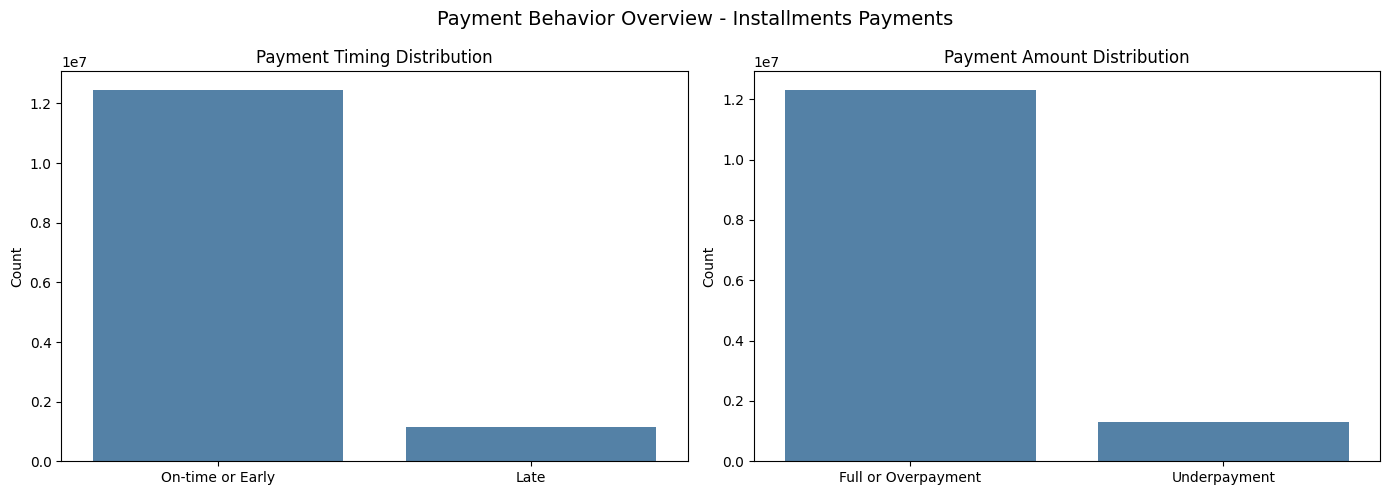

In [6]:
# Bar plot - payment behavior overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Late vs on-time
payment_timing = ['On-time or Early', 'Late']
payment_timing_counts = [on_time, late_payments]
sns.barplot(x=payment_timing, y=payment_timing_counts, ax=axes[0], color='steelblue')
axes[0].set_title('Payment Timing Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

# Underpayment vs full payment
payment_amount = ['Full or Overpayment', 'Underpayment']
payment_amount_counts = [
    (df_installments['AMT_PAYMENT_DIFF'] <= 0).sum(),
    underpayments
]
sns.barplot(x=payment_amount, y=payment_amount_counts, ax=axes[1], color='steelblue')
axes[1].set_title('Payment Amount Distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

plt.suptitle('Payment Behavior Overview - Installments Payments', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [7]:
# Missing value count and percentage
missing_inst = pd.DataFrame({
    'Missing Count': df_installments.isnull().sum(),
    'Missing (%)': (df_installments.isnull().sum() / len(df_installments) * 100).round(2)
})
missing_inst = missing_inst[missing_inst['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_inst.empty:
    print("No missing values found in installments_payments.")
else:
    print(missing_inst)

                    Missing Count  Missing (%)
DAYS_ENTRY_PAYMENT           2905         0.02
AMT_PAYMENT                  2905         0.02
DAYS_PAYMENT_DIFF            2905         0.02
AMT_PAYMENT_DIFF             2905         0.02


### Key Findings & Handling Strategy

The `installments_payments` dataset contains **4 features with missing values**, all with negligible missing rates. Note that `DAYS_PAYMENT_DIFF` and `AMT_PAYMENT_DIFF` are derived features created in Section 2, so their missing values are inherited from `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` respectively.

Key observations:
- `DAYS_ENTRY_PAYMENT` and `AMT_PAYMENT` (0.02%) are missing together for the same 2,905 rows, likely representing missed installments where no payment was made and therefore no entry date or amount was recorded.

**Handling Strategy:**
- `DAYS_ENTRY_PAYMENT`: impute with `DAYS_INSTALMENT` + a large penalty value (e.g. 365) to signal missed payment, or flag separately as `IS_MISSED_PAYMENT` binary indicator
- `AMT_PAYMENT`: impute with **0**, missing indicates no payment was made for that installment
- `DAYS_PAYMENT_DIFF`, `AMT_PAYMENT_DIFF`: will be resolved automatically after imputing the source features above
---

# 4. Numerical Features Analysis

Numerical features in `installments_payments` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

In [10]:
# Numerical features in installments_payments (exclude identifiers)
num_cols_inst = df_installments.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_inst = [col for col in num_cols_inst if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [11]:
# Statistical description
df_installments[num_cols_inst].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_INSTALMENT_VERSION,13605401.0,0.856637,1.035216,0.000,0.000,1.000,1.000,178.000
NUM_INSTALMENT_NUMBER,13605401.0,18.870896,26.664067,1.000,4.000,8.000,19.000,277.000
DAYS_INSTALMENT,13605401.0,-1042.269992,800.946284,-2922.000,-1654.000,-818.000,-361.000,-1.000
DAYS_ENTRY_PAYMENT,13602496.0,-1051.113684,800.585883,-4921.000,-1662.000,-827.000,-370.000,-1.000
AMT_INSTALMENT,13605401.0,17050.906989,50570.254429,0.000,4226.085,8884.080,16710.210,3771487.845
AMT_PAYMENT,13602496.0,17238.223250,54735.783981,0.000,3398.265,8125.515,16108.425,3771487.845
DAYS_PAYMENT_DIFF,13602496.0,-8.787405,25.539900,-3189.000,-14.000,-6.000,0.000,2884.000
AMT_PAYMENT_DIFF,13602496.0,-187.153772,19106.732113,-2630908.935,0.000,0.000,0.000,2424726.405


##### Key Findings

**Days Features (Negative Values by Design)**
`DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` are negative by design, representing days relative to application date. No transformation needed in EDA.

**Anomalies Detected**
- `DAYS_ENTRY_PAYMENT` min = **-4,921**, more negative than `DAYS_INSTALMENT` min of -2,922, suggesting some payments were recorded earlier than the earliest scheduled installment. Requires investigation.
- `DAYS_PAYMENT_DIFF` max = **2,884**, indicating extreme late payments of nearly 8 years. Requires capping before aggregation.
- `DAYS_PAYMENT_DIFF` min = **-3,189**, indicating extreme early payments. Likely anomalous and requires investigation.
- `AMT_PAYMENT_DIFF` min = **-2,630,908** and max = **2,424,726**, extreme values on both ends. Negative values indicate overpayments while positive values indicate underpayments. Both extremes require capping.
- `NUM_INSTALMENT_VERSION` max = **178**, extreme outlier suggesting a loan with 178 restructuring versions. Requires investigation.

**Derived Features (Section 2)**
- `DAYS_PAYMENT_DIFF` mean = -8.79 and median = -6, confirming most payments are made slightly early on average. Positive values indicate late payments.
- `AMT_PAYMENT_DIFF` median = 0, confirming most installments are paid in full. Positive values indicate underpayments.

**Skewed Distributions**
- `AMT_INSTALMENT` mean 17,051 vs median 8,884, heavily right-skewed. Max of 3,771,488 confirms extreme outliers.
- `AMT_PAYMENT` shows similar pattern with mean 17,238 vs median 8,126.
- `NUM_INSTALMENT_NUMBER` mean 18.87 vs median 8, heavily right-skewed reflecting varying loan term lengths.

**Features for Further Analysis**
- `DAYS_PAYMENT_DIFF` to confirm distribution of payment delays
- `AMT_PAYMENT_DIFF` to examine underpayment and overpayment patterns
- `AMT_INSTALMENT` and `AMT_PAYMENT` to confirm skewness and outlier severity

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

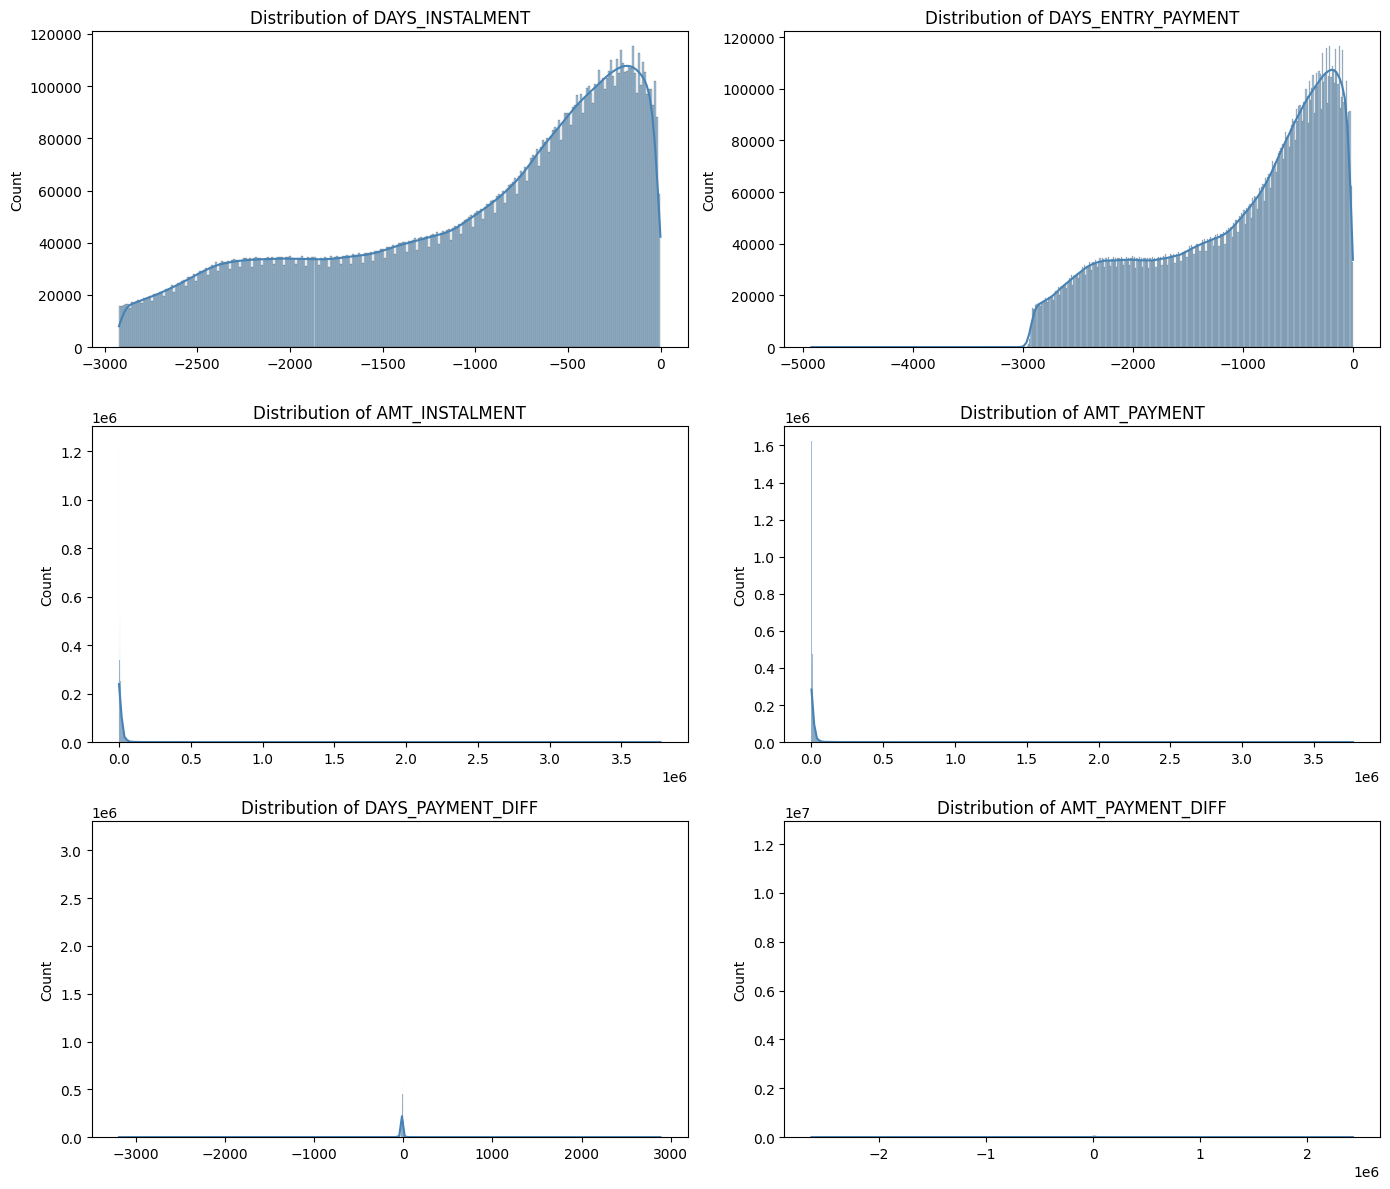

In [12]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
    'AMT_INSTALMENT', 'AMT_PAYMENT',
    'DAYS_PAYMENT_DIFF', 'AMT_PAYMENT_DIFF'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_installments[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT` show similar left-skewed distributions concentrated near 0, confirming most installment records are recent relative to application date. `DAYS_ENTRY_PAYMENT` extends further left to -4,921, confirming the anomalous early payment records noted in stat desc.
- `AMT_INSTALMENT` and `AMT_PAYMENT` are both extremely right-skewed with the vast majority compressed near zero and long tails extending to 3.7M. Both show near-identical distribution shapes, confirming most payments match their scheduled amounts. **Capping recommended.**
- `DAYS_PAYMENT_DIFF` is sharply concentrated near 0 with symmetric tails extending to -3,189 (early) and +2,884 (late), confirming most payments are made close to schedule. The distribution is slightly left-skewed, consistent with the mean of -8.79 days indicating payments tend to be made slightly early.
- `AMT_PAYMENT_DIFF` is heavily compressed near 0 with extreme outliers on both sides extending to -2.6M (overpayment) and +2.4M (underpayment). The vast majority of installments are paid in full. **Capping recommended.**

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

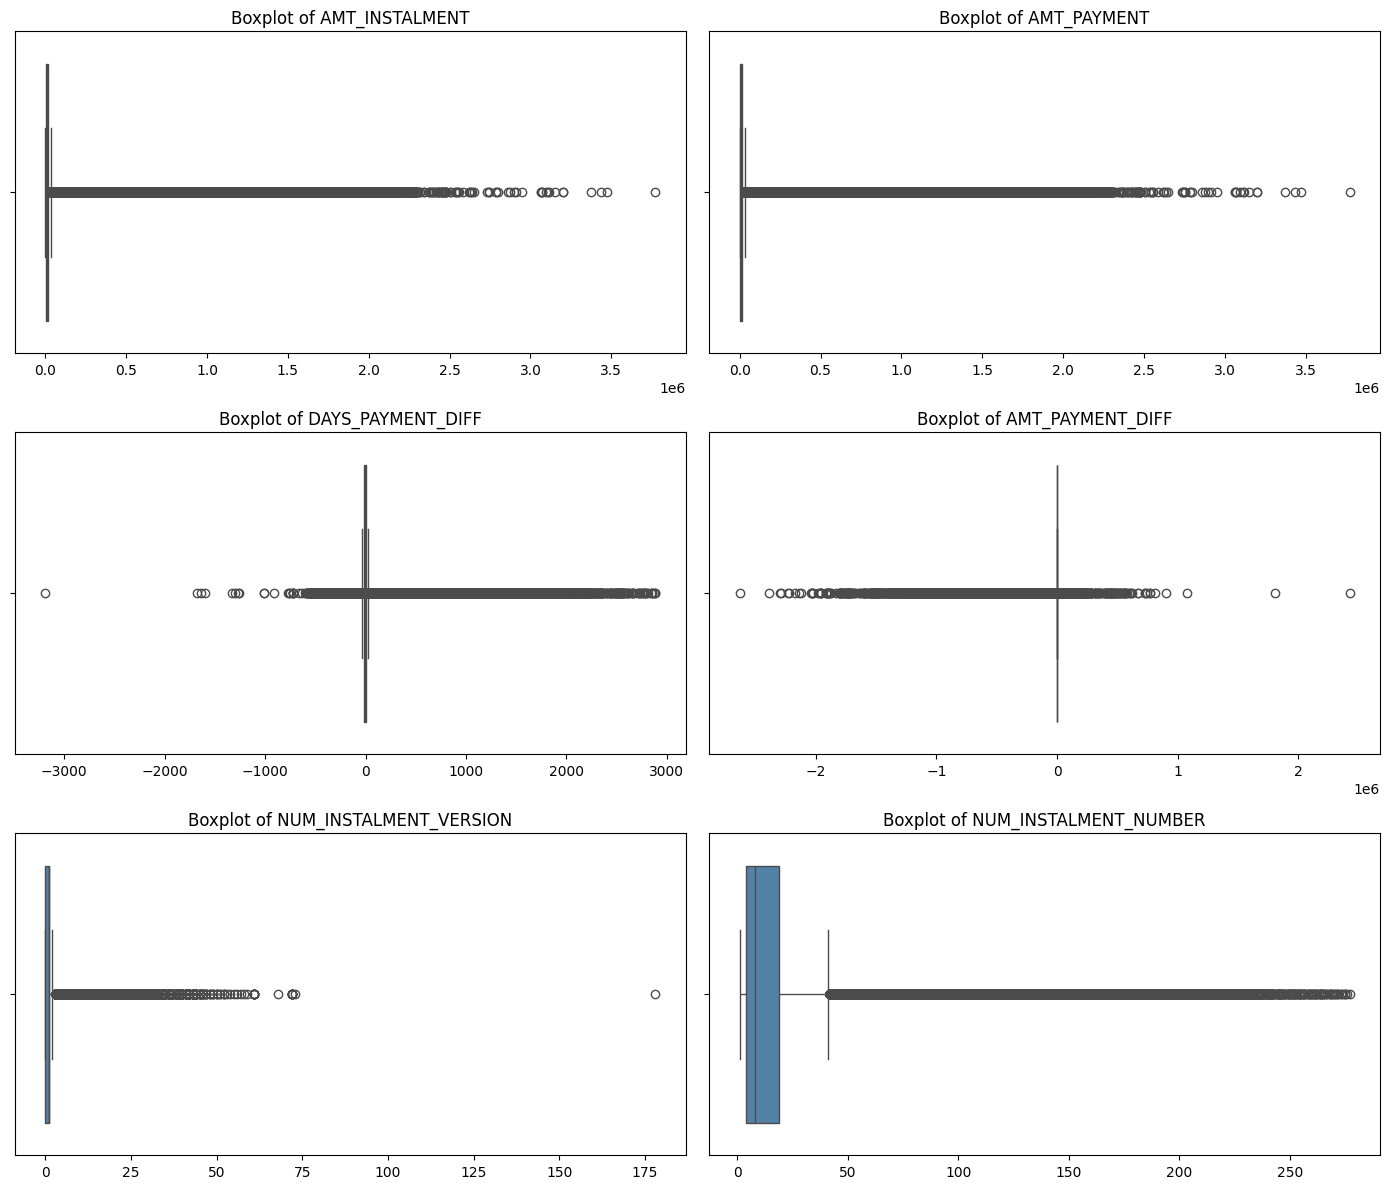

In [13]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_INSTALMENT', 'AMT_PAYMENT',
    'DAYS_PAYMENT_DIFF', 'AMT_PAYMENT_DIFF',
    'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_installments[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


##### Key Findings

- `AMT_INSTALMENT` and `AMT_PAYMENT` show extreme outliers extending to 3.7M with IQR compressed near zero, **needs capping.**
- `DAYS_PAYMENT_DIFF` shows extreme outliers on both sides (-3,189 to +2,884), **needs capping at both tails.**
- `AMT_PAYMENT_DIFF` shows extreme outliers on both sides extending to 2.4M, **needs capping at both tails.**
- `NUM_INSTALMENT_VERSION` shows extreme outlier at 178, **needs investigation and capping.**
- `NUM_INSTALMENT_NUMBER` shows moderate spread up to 277 with sparse outliers, reasonable range for long-term loans.

All derived features and amount features require outlier treatment before aggregation. Special attention needed for bilateral outliers in `DAYS_PAYMENT_DIFF` and `AMT_PAYMENT_DIFF`.

---